In [1]:
from pathlib import Path
notebook_dir = Path().resolve()
data_path = notebook_dir.parent / "img" / "secom.csv"
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import datetime as dt
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # or 'Noto Sans TC'
plt.rcParams['axes.unicode_minus'] = False
from collections import Counter, defaultdict
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from scipy import stats as sps
from sklearn.base import clone
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score, r2_score, mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, _tree, plot_tree
from xgboost import XGBClassifier, XGBRegressor


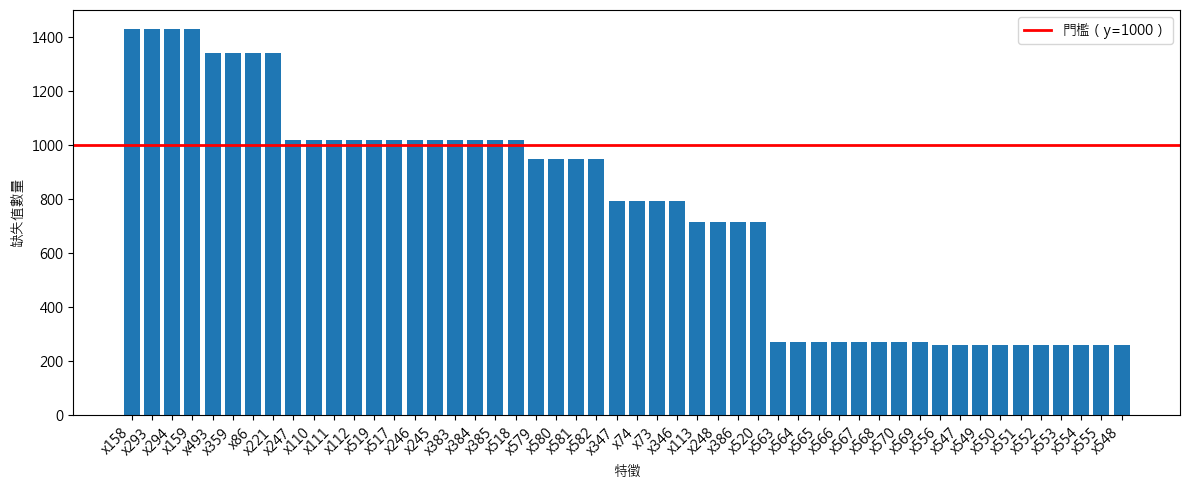

In [5]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1: 0, 1: 1}).astype(int)

na_cnt = X.isna().sum().sort_values(ascending=False)

topk = 50
na_top = na_cnt.head(topk)
x_ticks = na_top.index.tolist()

plt.figure(figsize=(12, 5))
plt.bar(range(len(na_top)), na_top.values)
plt.xticks(range(len(na_top)), x_ticks, rotation=45, ha='right')
plt.axhline(y=1000, color='r', linewidth=2, label='門檻（y=1000）')
plt.xlabel("特徵")
plt.ylabel("缺失值數量")
plt.legend()
plt.tight_layout()
plt.show()

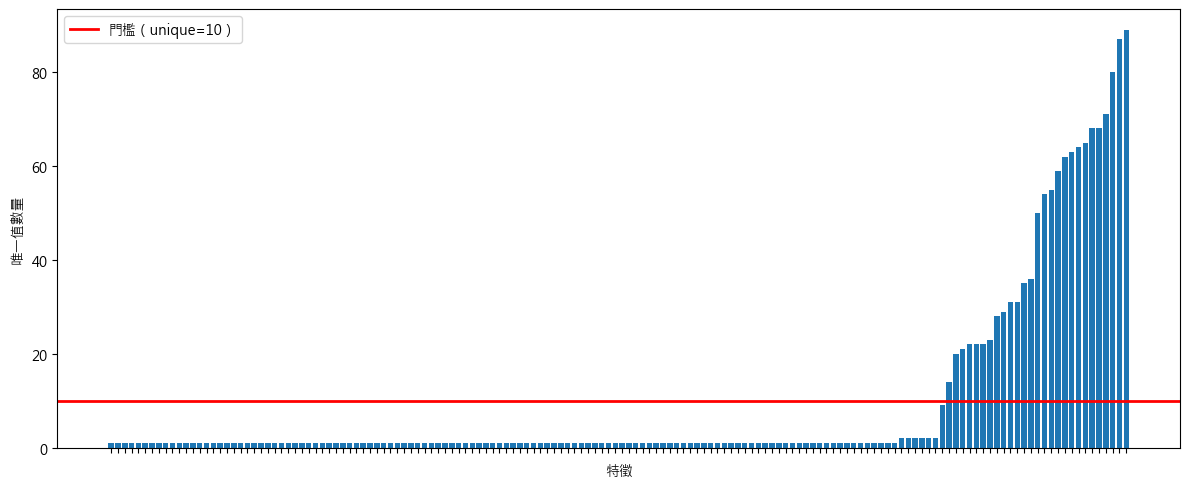

In [6]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()

uniq_counts = X.nunique(dropna=True).sort_values(ascending=True)

topk = 150
na_top = uniq_counts.head(topk)
x_ticks = na_top.index.tolist()

plt.figure(figsize=(12, 5))
plt.bar(range(len(na_top)), na_top.values)
plt.xticks(ticks=range(len(na_top)), labels=[''] * len(na_top))
plt.axhline(y=10, color='r', linewidth=2, label='門檻（unique=10）')

plt.xlabel("特徵")
plt.ylabel("唯一值數量")
plt.legend()
plt.tight_layout()
plt.show()

PCA 保留 131 個主成分


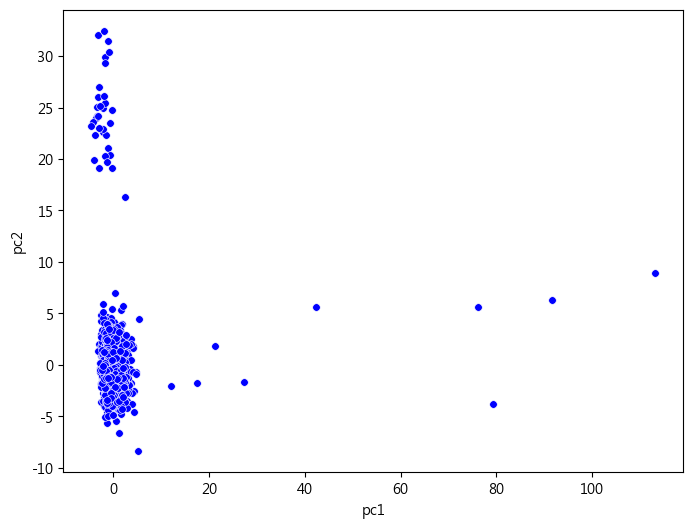

In [15]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', s=30, color='b')
plt.show()

PCA 保留 131 個主成分
cluster sizes: {0: 1563, 1: 4}
cluster     0  1
y               
0        1460  3
1         103  1


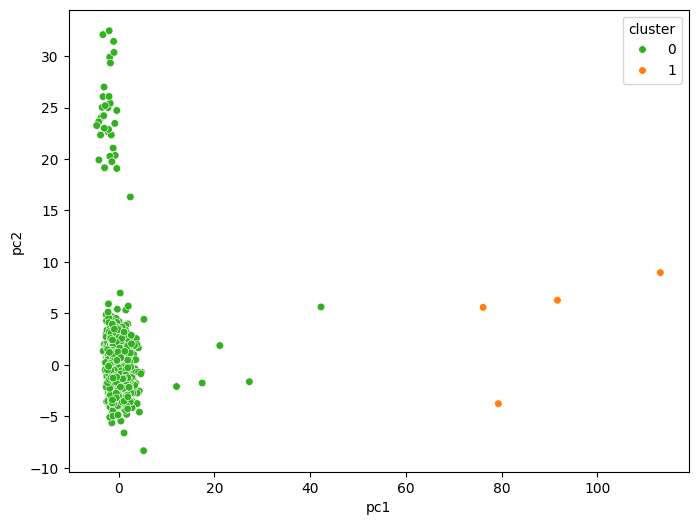

In [39]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['cluster'] = labels

plt.figure(figsize=(8,6))
palette = {
    0: "#33B020",  # cluster 0, y=1
    1: '#ff7f0e',  # cluster 1, y=0
}
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='cluster', s=30, palette=palette)
plt.show()

PCA 保留 126 個主成分
cluster sizes: {0: 60, 1: 2134}
cluster   0     1
y                
0        25  1438
1        35   696


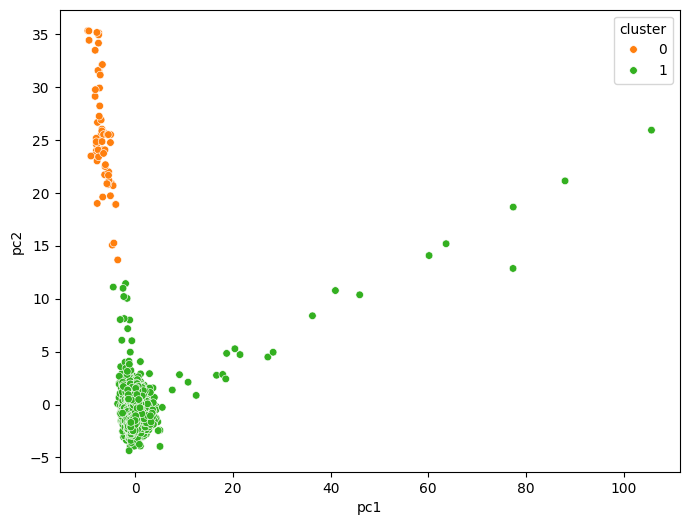

In [ ]:
secom = pd.read_csv(data_path, sep='\t')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_smote_df)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y_smote.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['cluster'] = labels

plt.figure(figsize=(8,6))
palette = {
    1: "#33B020",  # cluster 0, y=1
    0: '#ff7f0e',  # cluster 1, y=0
}
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='cluster', s=30, palette=palette)
plt.show()

In [26]:
X_std

,x1,x2,x3,x4,x5,x7,x8,x9,x10,x11,...,x581,x582,x583,x584,x585,x586,x587,x588,x589,x590
0,0.226256,0.849585,-0.437725,0.031878,-0.051283,-0.561426,0.259460,0.509879,1.128456,-0.381062,...,-0.355724,-0.223358,0.118598,-0.204833,-0.093161,-0.197057,-0.274824,-0.151848,-0.059407,0.192825
1,1.108470,-0.382864,1.015222,0.151244,-0.060737,0.199930,0.311127,0.457057,0.022641,-1.607666,...,0.284530,2.002291,0.530099,0.406734,0.444751,0.385114,-0.959976,0.411947,0.250162,1.156552
2,-1.111280,0.798970,-0.482727,0.683739,-0.048612,-0.903553,0.249126,-0.260788,0.327237,0.124643,...,4.535343,-0.167107,-1.262870,0.022320,0.014421,0.029888,2.991254,3.627134,3.321453,-0.179270
3,-0.347965,-0.198856,-0.053121,-1.107231,-0.051992,0.504698,0.001121,0.343285,-0.765335,-0.370303,...,-0.488345,-0.323168,-0.322296,-0.292200,-0.362117,-0.283360,-0.101717,-0.178829,-0.308255,-0.275366
4,0.244077,0.087501,1.115440,-0.160361,-0.048199,-0.113401,0.187125,0.545094,-0.149522,-0.789930,...,0.089124,0.421793,-5.906953,26.867220,27.071426,26.913337,-0.101717,-0.178829,-0.308255,-0.275366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1562,-1.562930,-0.392587,-0.710010,3.836040,-0.049073,-3.034883,0.321461,-1.631465,-0.242225,-0.628535,...,-0.343431,1.915191,-0.381082,-0.059222,0.014421,-0.056136,-1.186686,-0.303801,-0.203551,1.102920
1563,0.517108,0.332844,-0.069003,-0.619020,-0.059902,-0.423706,-0.122881,-0.400294,-0.348171,-1.015884,...,0.424439,0.351519,-0.763190,-0.129115,-0.066266,-0.124121,-1.186686,-0.303801,-0.203551,1.102920
1564,-0.482779,-1.447013,0.194206,-0.651200,-0.060840,-0.271869,-0.091881,0.282905,-0.208331,-0.418339,...,-1.406134,-0.847934,-0.410475,-0.000977,0.068213,-0.002413,-0.142201,-0.894577,-0.971374,-0.598494
1565,-1.624011,0.450778,-0.801907,-0.484805,-0.047500,-0.370765,-0.040213,-0.008865,-0.421009,0.329077,...,1.009100,0.016940,0.089205,0.144634,-0.012474,0.139431,0.384090,0.911835,0.773678,-0.065942


PCA 保留 137 個主成分
cluster sizes: {0: 718, 1: 807}
cluster    0    1
y                
0        660  770
1         58   37


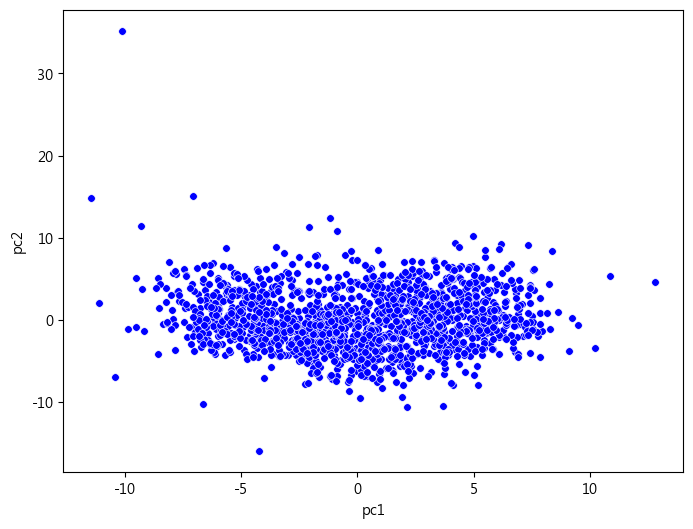

In [ ]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', s=30, color='b')
plt.show()

PCA 保留 137 個主成分
cluster sizes: {0: 718, 1: 807}
cluster    0    1
y                
0        660  770
1         58   37


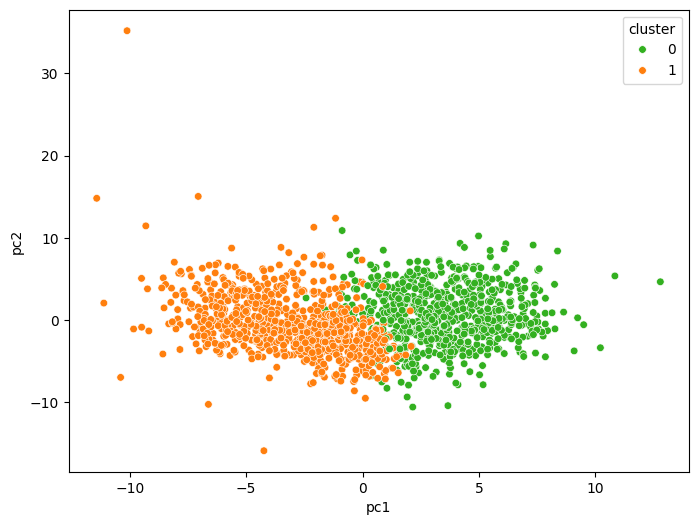

In [38]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['cluster'] = labels

plt.figure(figsize=(8,6))
palette = {
    0: "#33B020",  # cluster 0, y=1
    1: '#ff7f0e',  # cluster 1, y=0
}
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='cluster', s=30, palette=palette)
plt.show()

PCA 保留 125 個主成分


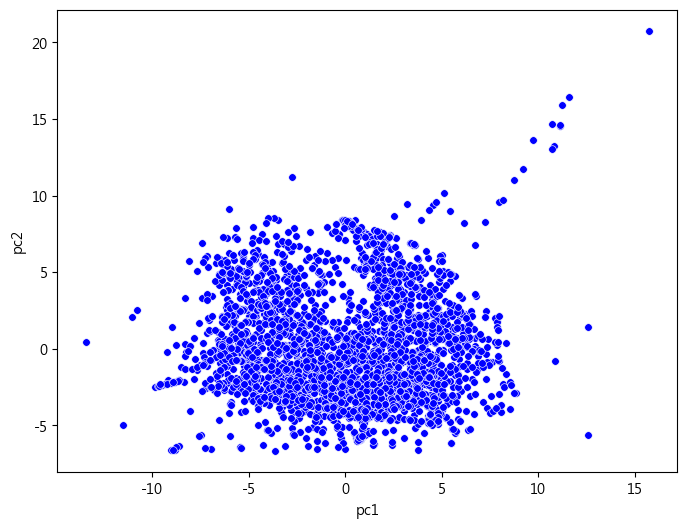

In [11]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_std, y)
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_smote_df)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', s=30, color='b')
plt.show()

PCA 保留 125 個主成分


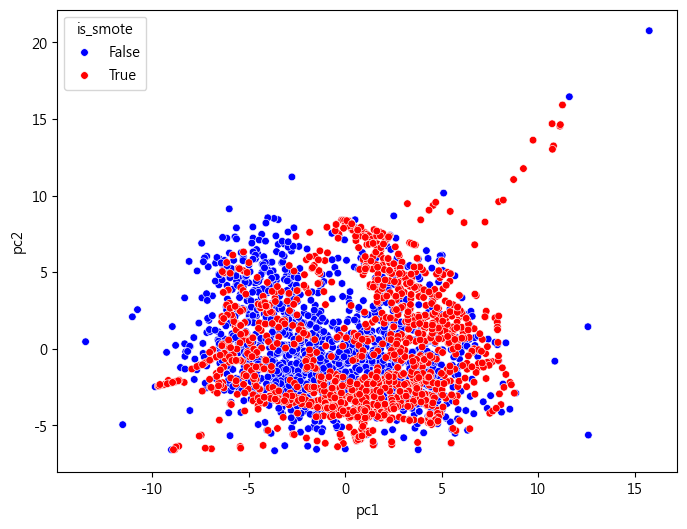

In [16]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
# 1) 在 SMOTE 後保留 index（最低限度修改：只加這兩行）
X_smote, y_smote = smote.fit_resample(X_std, y)
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns, index=X_smote.index)

# 2) PCA 後把「是否為合成樣本」帶到投影空間
pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_smote_df)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)], index=X_smote_df.index)

# 3) 合成樣本判定：SMOTE 新增的那些 index 不在原始 X_std.index
X_pca_df['is_smote'] = ~X_pca_df.index.isin(X_std.index)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=X_pca_df, x='pc1', y='pc2',
    hue='is_smote', palette={False:'b', True:'r'},
    s=30, legend=True
)
plt.show()


PCA 保留 125 個主成分
cluster sizes: {0: 1548, 1: 1312}
cluster    0    1
y                
0        619  811
1        929  501


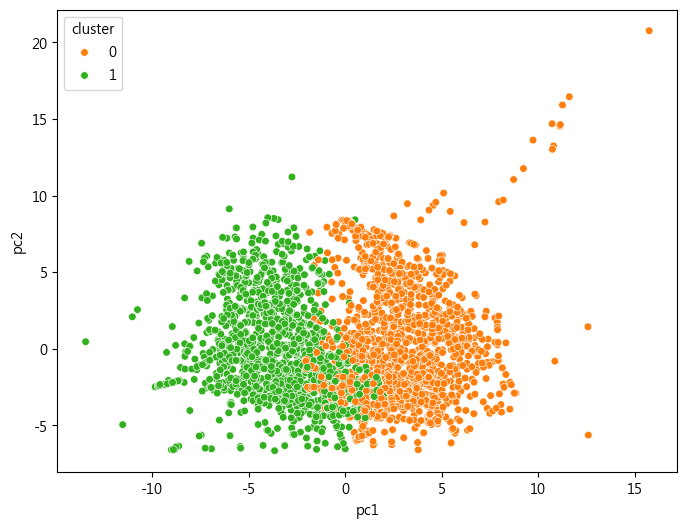

In [13]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_std, y)
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_smote_df)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y_smote.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['cluster'] = labels

plt.figure(figsize=(8,6))
palette = {
    1: "#33B020",  # cluster 0, y=1
    0: '#ff7f0e',  # cluster 1, y=0
}
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='cluster', s=30, palette=palette)
plt.show()

In [61]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

# X_smote, y_smote 已經是你前面做完 SMOTE 後的標準化空間資料
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

# 1) 在同一個 SMOTE 空間做 PCA + KMeans，得到 cluster
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_smote_df)
n_real = len(X_std)

# 必要斷言：確保前段就是原始點
assert np.allclose(X_smote_df.iloc[:n_real].values, X_std.values, atol=0, rtol=0)
assert np.array_equal(np.asarray(y_smote)[:n_real], np.asarray(y))

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)

# X_smote_df 目前包含所有特徵 + "cluster"
X_smote_df["cluster"] = cluster

# 確保 X_all_df 不含 cluster 欄
X_feat_df = X_smote_df.drop(columns=["cluster"]).copy()
# 只取真實點（不含 SMOTE 合成點）來做 local surrogate 與訓練每群 blackbox
X_all_df = X_feat_df.iloc[:n_real].copy() # 真實點特徵（標準化空間）
c_all = X_smote_df.loc[:n_real-1, "cluster"].to_numpy() # 真實點分群
y_real = np.asarray(y) # 真實 y

PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個


C:\Users\USER\AppData\Local\Temp\ipykernel_29352\2691304449.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_smote_df["cluster"] = cluster


In [69]:
print("cluster counts:\n", pd.Series(c_all).value_counts().sort_index())

cluster counts:
 0    772
1    753
Name: count, dtype: int64


In [72]:
def compute_metrics(y_true, y_pred, y_score):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP = cm[0,0], cm[0,1]
    acc = accuracy_score(y_true, y_pred)
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    ROCAU = roc_auc_score(y_true, y_score) if np.unique(y_true).size == 2 else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'ROCAU':ROCAU}

def predict_score(clf, X):
    if hasattr(clf, "predict_proba"):
        return clf.predict_proba(X)[:, 1]
    if hasattr(clf, "decision_function"):
        s = clf.decision_function(X)
        return 1 / (1 + np.exp(-s))
    return clf.predict(X).astype(float)

model = {'XGBoost':XGBClassifier(
                    n_estimators=300,
                    max_depth=3,
                    learning_rate=0.1,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    min_child_weight=10,
                    gamma=1.0,
                    reg_lambda=2.0,
                    reg_alpha=0.5,
                    random_state=42,
                    n_jobs=-1,
                    objective="binary:logistic",
                    eval_metric="logloss",
                    tree_method="hist",)}

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)

cv_results = []
for name, clf in model.items():
    fold_metrics = []
    cm_sum = np.zeros((2, 2), dtype=float)
    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_all_df, y_real), 1):
        Xtr, Xte = X_all_df.iloc[train_idx], X_all_df.iloc[test_idx]
        ytr, yte = y_real[train_idx], y_real[test_idx]

        # 只對訓練集做 SMOTE
        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        m = clone(clf)
        m.fit(Xtr_res, ytr_res)
        yhat = predict_labels(m, Xte)
        ys   = predict_score(m, Xte)
        
        met  = compute_metrics(yte, yhat, ys)
        fold_metrics.append(met)
        cm_sum += met["cm"]
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, ROCAU={met['ROCAU']:.3f}")

    # 平均每個 fold 的結果
    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

    # 額外輸出：5 折平均 confusion matrix
    cm_mean = cm_sum / skf.get_n_splits()
    print("\nConfusion matrix (mean over 5 folds):")
    print(cm_mean)
    
# ====== 結果輸出 ======
metrics_df = pd.DataFrame(cv_results).set_index('model').loc[model.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))


=== XGBoost ===
Fold 1: acc=0.928, FAR=0.014, ROCAU=0.649
Fold 2: acc=0.931, FAR=0.017, ROCAU=0.703
Fold 3: acc=0.931, FAR=0.010, ROCAU=0.603
Fold 4: acc=0.931, FAR=0.010, ROCAU=0.706
Fold 5: acc=0.938, FAR=0.010, ROCAU=0.723

Confusion matrix (mean over 5 folds):
[[282.4   3.6]
 [ 17.2   1.8]]

Summary (5-Fold mean):
             acc     FAR   ROCAU
model                          
XGBoost  0.9318  0.0126  0.6767


In [ ]:
mask = (c_all == 0)
X_sub = X_all_df.loc[mask].values
y_sub = y.loc[mask].values

def compute_metrics(y_true, y_pred, y_score):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP = cm[0,0], cm[0,1]
    acc = accuracy_score(y_true, y_pred)
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    ROCAU = roc_auc_score(y_true, y_score) if np.unique(y_true).size == 2 else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'ROCAU':ROCAU}

def predict_score(clf, X):
    if hasattr(clf, "predict_proba"):
        return clf.predict_proba(X)[:,1]
    if hasattr(clf, "decision_function"):
        s = clf.decision_function(X)
        return 1 / (1 + np.exp(-s))
    return clf.predict(X).astype(float)

model = {'XGBoost':XGBClassifier(
                    n_estimators=300,
                    max_depth=3,
                    learning_rate=0.1,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    min_child_weight=10,
                    gamma=1.0,
                    reg_lambda=2.0,
                    reg_alpha=0.5,
                    random_state=42,
                    n_jobs=-1,
                    objective="binary:logistic",
                    eval_metric="logloss",
                    tree_method="hist",)}

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for name, clf in model.items():
    fold_metrics = []
    cm_sum = np.zeros((2, 2), dtype=float)
    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):
        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]
        
        smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
        # 只對訓練集做 SMOTE
        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        m = clone(clf)
        m.fit(Xtr_res, ytr_res)

        yhat = predict_labels(m, Xte)
        ys   = predict_score(m, Xte)

        met = compute_metrics(yte, yhat, ys)
        fold_metrics.append(met)
        cm_sum += met["cm"]
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, ROCAU={met['ROCAU']:.3f}")

    # 平均每個 fold 的結果
    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

    # 額外輸出：5 折平均 confusion matrix
    cm_mean = cm_sum / skf.get_n_splits()
    print("\nConfusion matrix (mean over 5 folds):")
    print(cm_mean)

# ====== 結果輸出 ======
metrics_df = pd.DataFrame(cv_results).set_index('model').loc[model.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))


=== XGBoost ===
Fold 1: acc=0.948, FAR=0.013, ROCAU=0.800
Fold 2: acc=0.955, FAR=0.007, ROCAU=0.661
Fold 3: acc=0.948, FAR=0.020, ROCAU=0.746
Fold 4: acc=0.968, FAR=0.000, ROCAU=0.715
Fold 5: acc=0.961, FAR=0.000, ROCAU=0.534

Confusion matrix (mean over 5 folds):
[[147.4   1.2]
 [  5.6   0.2]]

Summary (5-Fold mean):
            acc     FAR   ROCAU
model                         
XGBoost  0.956  0.0081  0.6912


In [71]:
mask = (c_all == 1)
X_sub = X_all_df.loc[mask].values
y_sub = y.loc[mask].values

def compute_metrics(y_true, y_pred, y_score):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP = cm[0,0], cm[0,1]
    acc = accuracy_score(y_true, y_pred)
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    ROCAU = roc_auc_score(y_true, y_score) if np.unique(y_true).size == 2 else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'ROCAU':ROCAU}

def predict_score(clf, X):
    if hasattr(clf, "predict_proba"):
        return clf.predict_proba(X)[:,1]
    if hasattr(clf, "decision_function"):
        s = clf.decision_function(X)
        return 1 / (1 + np.exp(-s))
    return clf.predict(X).astype(float)

model = {'XGBoost':XGBClassifier(
                    n_estimators=300,
                    max_depth=3,
                    learning_rate=0.1,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    min_child_weight=10,
                    gamma=1.0,
                    reg_lambda=2.0,
                    reg_alpha=0.5,
                    random_state=42,
                    n_jobs=-1,
                    objective="binary:logistic",
                    eval_metric="logloss",
                    tree_method="hist",)}

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for name, clf in model.items():
    fold_metrics = []
    cm_sum = np.zeros((2, 2), dtype=float)
    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):
        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]
        
        smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
        # 只對訓練集做 SMOTE
        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        m = clone(clf)
        m.fit(Xtr_res, ytr_res)

        yhat = predict_labels(m, Xte)
        ys   = predict_score(m, Xte)

        met = compute_metrics(yte, yhat, ys)
        fold_metrics.append(met)
        cm_sum += met["cm"]
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, ROCAU={met['ROCAU']:.3f}")

    # 平均每個 fold 的結果
    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

    # 額外輸出：5 折平均 confusion matrix
    cm_mean = cm_sum / skf.get_n_splits()
    print("\nConfusion matrix (mean over 5 folds):")
    print(cm_mean)

# ====== 結果輸出 ======
metrics_df = pd.DataFrame(cv_results).set_index('model').loc[model.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))


=== XGBoost ===
Fold 1: acc=0.841, FAR=0.087, ROCAU=0.615
Fold 2: acc=0.907, FAR=0.014, ROCAU=0.530
Fold 3: acc=0.881, FAR=0.036, ROCAU=0.774
Fold 4: acc=0.907, FAR=0.022, ROCAU=0.802
Fold 5: acc=0.920, FAR=0.015, ROCAU=0.642

Confusion matrix (mean over 5 folds):
[[132.6   4.8]
 [ 11.6   1.6]]

Summary (5-Fold mean):
             acc     FAR   ROCAU
model                          
XGBoost  0.8912  0.0349  0.6724
